# Feature scaling and why gradient descent crawls without it

We fit a **hyperplane** with two features,

$$\hat{y} = w_1 x_1 + w_2 x_2,$$

to data $(x_i, y_i)$ by minimising the squared cost $J(w_1, w_2)$. (The bias
term is dropped so the cost lives in the $(w_1, w_2)$ plane, which we can draw.)

Both features carry the same signal strength, but live on **very different
scales**: $x_1 \in [0, 1]$ while $x_2$ spans hundreds. This notebook shows how
scale alone turns the convex cost bowl into a long narrow **canyon**, forces
gradient descent to shrink its learning rate to survive, and makes the walk
zig-zag — and how **standardising** the features rounds the bowl back into a
circle so the very same algorithm converges orders of magnitude faster.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import FloatSlider, IntSlider, interact

rng = np.random.default_rng(42)
n_samples = 80
u1 = rng.uniform(0, 1, n_samples)
u2 = rng.uniform(0, 1, n_samples)
noise = rng.normal(0, 0.05, size=n_samples)


def make_dataset(ratio):
    """Build features whose scales differ by `ratio`, carrying equal signal.

    The target depends only on the unit variables (u1, u2): changing `ratio`
    relabels the units of x2 without changing the underlying relationship.

    Example: make_dataset(100)[0][:, 1].max() -> ~100 while column 0 stays <= 1.
    """
    x = np.column_stack([u1, ratio * u2])
    y = 2.0 * u1 + 0.5 * u2 + noise
    return x, y

In [6]:
def squared_cost(weights, x, targets):
    residual = targets - x @ weights
    return float(np.mean(residual**2))


def squared_gradient(weights, x, targets):
    residual = targets - x @ weights
    return -2.0 * np.mean(residual[:, None] * x, axis=0)


def run_gradient_descent(x, targets, weights_start, alpha, steps):
    weights = np.asarray(weights_start, dtype=float)
    trail = [weights.copy()]
    for _ in range(steps):
        weights -= alpha * squared_gradient(weights, x, targets)
        trail.append(weights.copy())
    return np.array(trail)


def least_squares_weights(x, targets):
    return np.linalg.lstsq(x, targets, rcond=None)[0]


def standardize(x):
    return (x - x.mean(axis=0)) / x.std(axis=0)


def curvature_ratio(x):
    """How elongated the cost bowl is: largest / smallest Hessian eigenvalue."""
    eigenvalues = np.linalg.eigvalsh(2.0 / len(x) * x.T @ x)
    return float(eigenvalues[-1] / eigenvalues[0])


def cost_grid(x, targets, w1_range, w2_range, points=120):
    w1s = np.linspace(*w1_range, points)
    w2s = np.linspace(*w2_range, points)
    w1_mesh, w2_mesh = np.meshgrid(w1s, w2s)
    costs = np.array(
        [
            squared_cost(np.array([w1, w2]), x, targets)
            for w1, w2 in zip(w1_mesh.ravel(), w2_mesh.ravel(), strict=False)
        ]
    ).reshape(w1_mesh.shape)
    return w1_mesh, w2_mesh, costs

## 1. Two features on very different scales

$x_2$ is measured in units $100\times$ larger than $x_1$, yet both feed the
same amount of signal into $y$. The consequence sits in the *parameters*: a
fixed prediction error can be cancelled by a tiny nudge of $w_2$ but needs a
large change of $w_1$, so the gradients along the two axes differ by orders of
magnitude.

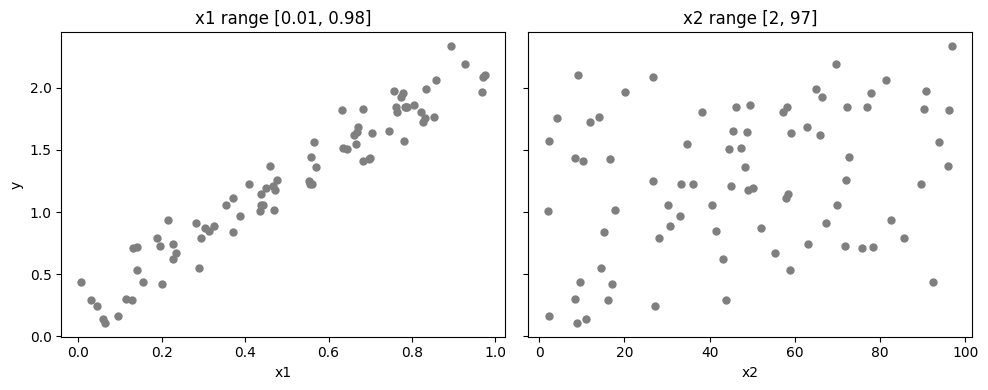

In [7]:
x_raw, y_raw = make_dataset(ratio=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1.scatter(x_raw[:, 0], y_raw, s=25, color="tab:gray")
ax1.set_title(f"x1 range [{x_raw[:, 0].min():.2f}, {x_raw[:, 0].max():.2f}]")
ax1.set_xlabel("x1")
ax2.scatter(x_raw[:, 1], y_raw, s=25, color="tab:gray")
ax2.set_title(f"x2 range [{x_raw[:, 1].min():.0f}, {x_raw[:, 1].max():.0f}]")
ax2.set_xlabel("x2")
ax1.set_ylabel("y")
plt.tight_layout()
plt.show()

## 2. The unscaled cost surface is a narrow canyon

Contouring $J(w_1, w_2)$ shows what unequal scales do to the geometry: the
convex bowl is squashed into an elongated valley whose width shrinks like
$1/\text{ratio}$ along $w_2$. The title reports the **curvature ratio**
$\lambda_{\max}/\lambda_{\min}$ of the Hessian $ \frac{2}{n} X^T X$ — it grows
like $\text{ratio}^2$. Gradient steps are perpendicular to the contours, so
they must fit inside the narrow axis.

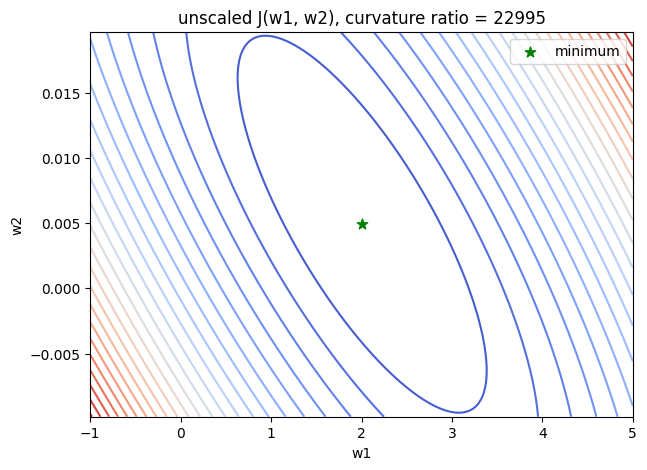

interactive(children=(FloatSlider(value=100.0, description='scale ratio', max=200.0, min=1.0, step=1.0), Outpu…

In [9]:
@interact(
    ratio=FloatSlider(
        min=1, max=200, step=1, value=100, description="scale ratio"
    ),
)
def plot_unscaled_bowl(ratio):
    x_data, y_data = make_dataset(ratio)
    w_star = least_squares_weights(x_data, y_data)

    w2_halfwidth = max(3.0 * abs(w_star[1]), 1e-3)
    w1_mesh, w2_mesh, costs = cost_grid(
        x_data,
        y_data,
        w1_range=(-1, 5),
        w2_range=(w_star[1] - w2_halfwidth, w_star[1] + w2_halfwidth),
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contour(w1_mesh, w2_mesh, costs, levels=25, cmap="coolwarm")
    ax.scatter(*w_star, color="green", s=60, marker="*", label="minimum")
    ax.set_title(
        f"unscaled J(w1, w2), curvature ratio = {curvature_ratio(x_data):.0f}"
    )
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.legend()
    plt.show()

## 3. Descent on raw features: zig-zag or diverge

Gradient descent is stable only while $\alpha < 2/\lambda_{\max}$, and the
large-$w_2$ direction sets $\lambda_{\max}$ — so the *whole* walk must use a
tiny learning rate. Progress along the gentle $w_1$ axis is then glacial: each
step shoots across the narrow canyon wall and barely creeps along its floor.

Drag $\alpha$ upward: just above $\approx 3\times10^{-4}$ the walk oscillates
across the valley and diverges; far below it converges but crawls.

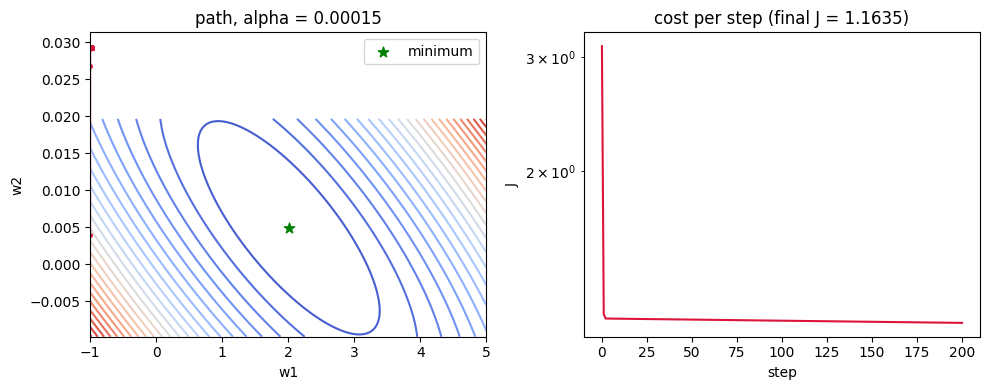

interactive(children=(FloatSlider(value=0.00015, description='learning rate', max=0.0006, min=5e-05, readout_f…

In [11]:
@interact(
    alpha=FloatSlider(
        min=0.00005,
        max=0.00060,
        step=0.00005,
        value=0.00015,
        description="learning rate",
        readout_format=".5f",
    ),
    steps=IntSlider(min=10, max=400, step=10, value=200, description="steps"),
)
def show_raw_descent(alpha, steps):
    x_data, y_data = make_dataset(ratio=100)
    w_star = least_squares_weights(x_data, y_data)

    w2_halfwidth = max(3.0 * abs(w_star[1]), 1e-3)
    w1_mesh, w2_mesh, costs = cost_grid(
        x_data,
        y_data,
        w1_range=(-1, 5),
        w2_range=(w_star[1] - w2_halfwidth, w_star[1] + w2_halfwidth),
    )
    trail = run_gradient_descent(x_data, y_data, (-1.0, 0.004), alpha, steps)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.contour(w1_mesh, w2_mesh, costs, levels=25, cmap="coolwarm")
    ax1.plot(
        trail[:, 0], trail[:, 1], color="crimson", lw=1.2, marker="o", ms=2.5
    )
    ax1.scatter(*w_star, color="green", s=60, marker="*", label="minimum")
    ax1.set_title(f"path, alpha = {alpha:.5f}")
    ax1.set_xlabel("w1")
    ax1.set_ylabel("w2")
    ax1.legend()

    ax2.plot(
        np.arange(len(trail)),
        [squared_cost(w, x_data, y_data) for w in trail],
        color="crimson",
        lw=1.5,
    )
    ax2.set_title(
        f"cost per step (final J = {squared_cost(trail[-1], x_data, y_data):.4f})"
    )
    ax2.set_xlabel("step")
    ax2.set_ylabel("J")
    ax2.set_yscale("log")
    plt.tight_layout()
    plt.show()

## 4. Standardisation rounds out the bowl

Replace each feature by its z-score,

$$z_j = \frac{x_j - \mu_j}{\sigma_j},$$

so every column has mean $0$ and variance $1$. The information is unchanged,
but now one unit of parameter change means the same thing along both axes: the
canyon snaps back into a round bowl, the curvature ratio collapses toward $1$,
and a learning rate hundreds of times larger becomes stable. Same algorithm,
same minimum location (in rescaled coordinates) — completely different
convergence speed.

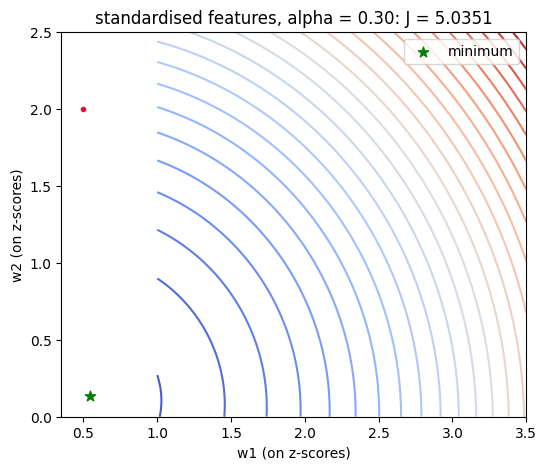

interactive(children=(IntSlider(value=0, description='step', max=40), Output()), _dom_classes=('widget-interac…

standardised curvature ratio: 1.13
raw curvature ratio:          22995


In [13]:
x_scaled = standardize(make_dataset(ratio=100)[0])
w_star_scaled = least_squares_weights(x_scaled, y_raw)

w1_mesh_s, w2_mesh_s, costs_s = cost_grid(
    x_scaled, y_raw, w1_range=(1, 3.5), w2_range=(0, 2.5)
)
trail_scaled = run_gradient_descent(x_scaled, y_raw, (0.5, 2.0), 0.3, 40)


@interact(
    step=IntSlider(
        min=0, max=len(trail_scaled) - 1, step=1, value=0, description="step"
    ),
)
def show_scaled_descent(step):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contour(w1_mesh_s, w2_mesh_s, costs_s, levels=25, cmap="coolwarm")
    ax.plot(
        trail_scaled[: step + 1, 0],
        trail_scaled[: step + 1, 1],
        color="crimson",
        lw=1.5,
        marker="o",
        ms=3,
    )
    ax.scatter(
        *w_star_scaled, color="green", s=60, marker="*", label="minimum"
    )
    ax.set_title(
        f"standardised features, alpha = 0.30: "
        f"J = {squared_cost(trail_scaled[step], x_scaled, y_raw):.4f}"
    )
    ax.set_xlabel("w1 (on z-scores)")
    ax.set_ylabel("w2 (on z-scores)")
    ax.legend()
    plt.show()


print(f"standardised curvature ratio: {curvature_ratio(x_scaled):.2f}")
print(f"raw curvature ratio:          {curvature_ratio(make_dataset(100)[0]):.0f}")

## 5. Head-to-head: cost per step

Each method runs at its best usable learning rate: $\alpha = 10^{-4}$ on raw
features (anything larger diverges) versus $\alpha = 0.3$ on standardised
features. The weights live in different coordinate systems, so we compare
costs, not paths. Standardising reaches the optimum in tens of steps where the
raw walk needs thousands — the model class never changed, only the geometry of
the bowl it has to roll down.

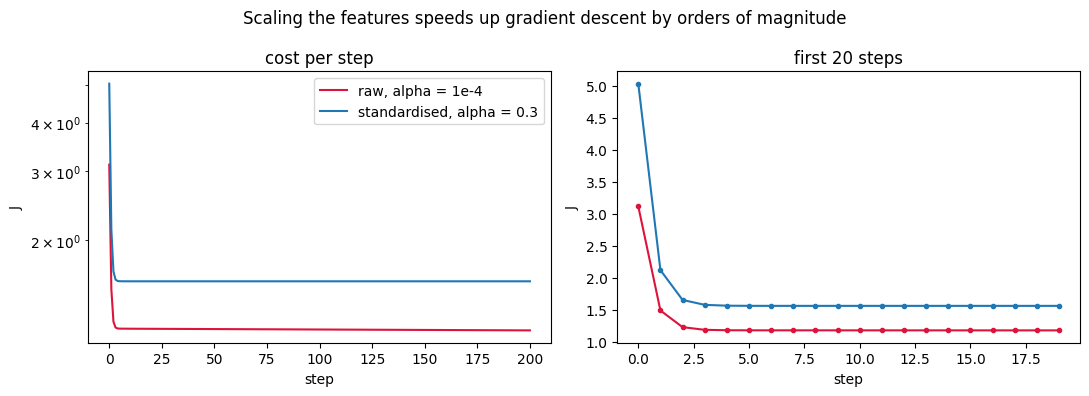

In [16]:
x_raw, y_raw = make_dataset(ratio=100)
x_scaled = standardize(x_raw)

steps_total = 200
trail_raw = run_gradient_descent(x_raw, y_raw, (-1.0, 0.004), 1e-4, steps_total)
trail_scaled = run_gradient_descent(x_scaled, y_raw, (0.5, 2.0), 0.3, steps_total)
costs_raw = [squared_cost(w, x_raw, y_raw) for w in trail_raw]
costs_scaled = [squared_cost(w, x_scaled, y_raw) for w in trail_scaled]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(costs_raw, color="crimson", lw=1.5, label="raw, alpha = 1e-4")
ax1.plot(
    costs_scaled, color="tab:blue", lw=1.5, label="standardised, alpha = 0.3"
)
ax1.set_yscale("log")
ax1.set_title("cost per step")
ax1.set_xlabel("step")
ax1.set_ylabel("J")
ax1.legend()

ax2.plot(costs_raw[:20], color="crimson", lw=1.5, marker="o", ms=3)
ax2.plot(costs_scaled[:20], color="tab:blue", lw=1.5, marker="o", ms=3)
ax2.set_title("first 20 steps")
ax2.set_xlabel("step")
ax2.set_ylabel("J")

fig.suptitle(
    "Scaling the features speeds up gradient descent by orders of magnitude"
)
plt.tight_layout()
plt.show()